<a href="https://colab.research.google.com/github/murtaza2k/AI_Residency/blob/main/Langchain_chains_agent_4apr26-v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Langchain setup

In [4]:
%pip install -Uq  openai==0.28.1 langchain==0.0.270 langchain-community

In [5]:
#secret Key

import os
from google.colab import userdata

# Retrieve API keys from Colab's secure storage

openai_api_key = userdata.get("openai")

# Set them as environment variables

if openai_api_key:
    os.environ["OPENAI_API_KEY"] = openai_api_key

## Chains

Restaraunt Business Generator

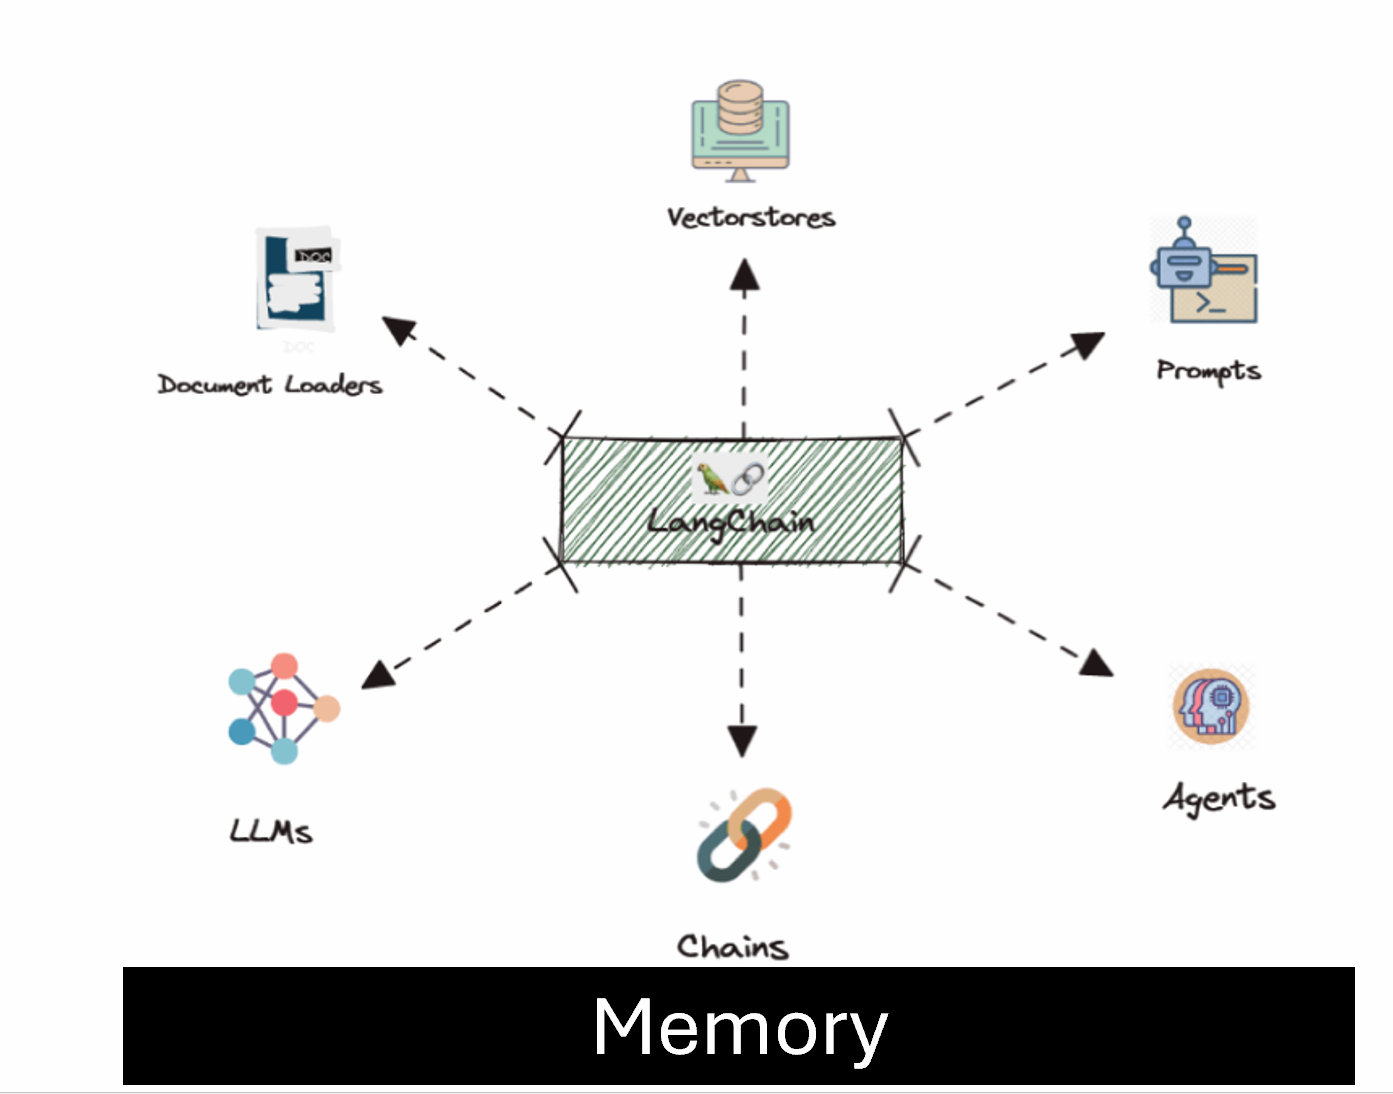

In [ ]:
from langchain.chains.llm import LLMChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.chains.sequential import SequentialChain
from langchain.chat_models import ChatOpenAI # Import ChatOpenAI

# Use ChatOpenAI with a chat-optimized model like gpt-3.5-turbo
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")

prompt_template_name= PromptTemplate(
    input_variables = ['cuisine'],
    template = "i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
                                         )


name_chain=LLMChain(llm=llm,prompt=prompt_template_name,output_key="restaraunt_name")




# Re-initialize llm with ChatOpenAI for the second chain as well
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")

prompt_template_items = PromptTemplate(input_variables=['restaraunt_name', 'cuisine'],
                                      template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names ,break down according to category like drinks soup starters main course"
                                       )

food_items_chain=LLMChain(llm=llm,prompt=prompt_template_items,output_key="menu_items")




chain = SequentialChain(
    chains = [name_chain, food_items_chain],
    input_variables =['cuisine'],
    output_variables = ['restaraunt_name','menu_items']
)


In [ ]:
chain({"cuisine": "Chinese"})

{'cuisine': 'Chinese',
 'restaraunt_name': '"Dragon\'s Palace"',
 'menu_items': "Drinks:\n1. Chinese Tea\n2. Sweet and Sour Punch\n3. Lychee Lemonade\n\nSoup:\n1. Hot and Sour Soup\n2. Won Ton Soup\n3. Egg Drop Soup\n\nStarters:\n1. Spring Rolls\n2. Pot Stickers\n3. Crab Rangoon\n\nMain Course:\n1. General Tso's Chicken\n2. Kung Pao Shrimp\n3. Beef with Broccoli\n4. Vegetable Lo Mein\n5. Szechuan Tofu\n\nHope this helps! Enjoy your meal at Dragon's Palace."}

In [ ]:
chain({"cuisine": "French"})

{'cuisine': 'French',
 'restaraunt_name': '"La délicieuse Maison"',
 'menu_items': "Drinks:\n1. Kir Royal (Champagne cocktail)\n2. Vin Rouge (Red wine)\n3. Crème de Cassis Fizz (Blackcurrant liqueur cocktail)\n\nSoup:\n1. Soupe à l'Oignon Gratinée (French onion soup)\n2. Crème de Champignons (Cream of mushroom soup)\n3. Bouillabaisse (Fish stew)\n\nStarters:\n1. Escargots de Bourgogne (Burgundy snails)\n2. Foie Gras (Goose liver pâté)\n3. Salade Niçoise (Salad with tuna, olives, and eggs)\n\nMain course:\n1. Coq au Vin (Chicken stewed in red wine)\n2. Boeuf Bourguignon (Beef stew with red wine)\n3. Ratatouille Provençale (Vegetable stew)\n\nDessert:\n1. Tarte Tatin (Apple tart)\n2. Crème Brûlée (Burnt cream custard)\n3. Profiteroles au Chocolat (Cream puffs filled with ice cream and chocolate sauce)"}

In [ ]:
pip install gradio

In [ ]:


import gradio as gr
from langchain.chains import LLMChain, SequentialChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI

# DDS Logo URL
DDS_LOGO_URL = "https://raw.githubusercontent.com/Decoding-Data-Science/airesidency/main/dds_logo.jpg"

# Define LLM chains as provided
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_name = PromptTemplate(
    input_variables=['cuisine'],
    template="i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
)
name_chain = LLMChain(llm=llm, prompt=prompt_template_name, output_key="restaraunt_name")

llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_items = PromptTemplate(
    input_variables=['restaraunt_name', 'cuisine'],
    template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names, break down according to category like drinks, soup, starters, main course"
)
food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items, output_key="menu_items")

chain = SequentialChain(
    chains=[name_chain, food_items_chain],
    input_variables=['cuisine'],
    output_variables=['restaraunt_name', 'menu_items']
)

# Popular cuisines dropdown options
TOP_CUISINES = [
    "Italian", "Chinese", "Japanese", "Mexican", "Indian",
    "French", "Thai", "Mediterranean", "American", "Spanish"
]

# Function to run the chain and return outputs
def generate_restaurant(cuisine):
    outputs = chain({'cuisine': cuisine})
    return outputs['restaraunt_name'], outputs['menu_items']

# Build Gradio interface
with gr.Blocks(title="Restaurant Business Generator", theme="default") as demo:
    with gr.Row():
        with gr.Column(scale=1, min_width=200):
            gr.Image(DDS_LOGO_URL, label="Decoding Data Science", elem_id="dds-logo")
            gr.Markdown(
                "**Restaurant Business Generator**  \n"
                "Choose a cuisine type, or select from popular options, then generate a restaurant name and menu instantly."
            )
            cuisine_dropdown = gr.Dropdown(choices=TOP_CUISINES, label="Popular Cuisines", value=TOP_CUISINES[0])
            generate_btn = gr.Button("Generate")
        with gr.Column(scale=2):
            name_output = gr.Textbox(label="Suggested Restaurant Name", interactive=False)
            menu_output = gr.Textbox(label="Suggested Menu Items", lines=10, interactive=False)

    generate_btn.click(fn=generate_restaurant, inputs=cuisine_dropdown, outputs=[name_output, menu_output])

if __name__ == "__main__":
    demo.launch()


/tmp/ipykernel_1540/1392028756.py:42: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Restaurant Business Generator", theme="default") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4cbeb675b9c9b33d06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from langchain.chains import LLMChain, SequentialChain
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI

# DDS Logo URL
DDS_LOGO_URL = "https://raw.githubusercontent.com/Decoding-Data-Science/airesidency/main/dds_logo.jpg"

# Define LLM chains as provided
llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_name = PromptTemplate(
    input_variables=['cuisine'],
    template="i want to open a restaraunt for  {cuisine} food. Suggest a fancy name for this"
)
name_chain = LLMChain(llm=llm, prompt=prompt_template_name, output_key="restaraunt_name")

llm = ChatOpenAI(temperature = 1, model_name="gpt-3.5-turbo")
prompt_template_items = PromptTemplate(
    input_variables=['restaraunt_name', 'cuisine'],
    template="Suggest me some menu items for {restaraunt_name} which is {cuisine} cuisine. Only mention items names, break down according to category like drinks, soup, starters, main course"
)
food_items_chain = LLMChain(llm=llm, prompt=prompt_template_items, output_key="menu_items")

chain = SequentialChain(
    chains=[name_chain, food_items_chain],
    input_variables=['cuisine'],
    output_variables=['restaraunt_name', 'menu_items']
)

# Popular cuisines dropdown options
TOP_CUISINES = [
    "Italian", "Chinese", "Japanese", "Mexican", "Indian",
    "French", "Thai", "Mediterranean", "American", "Spanish"
]

# Function to run the chain and return outputs
def generate_restaurant(cuisine):
    outputs = chain({'cuisine': cuisine})
    return outputs['restaraunt_name'], outputs['menu_items']

In [ ]:
generate_restaurant("Indian")

('"Maharaja\'s Tandoor Palace"',
 'Drinks:\n1. Mango Lassi\n2. Masala Chai\n\nSoup:\n1. Mulligatawny Soup\n2. Lentil Soup\n\nStarters:\n1. Samosas\n2. Pakoras\n3. Tandoori Chicken\n4. Aloo Tikki\n\nMain Course:\n1. Chicken Tikka Masala\n2. Lamb Rogan Josh\n3. Paneer Butter Masala\n4. Vegetable Biryani\n5. Dal Makhani\n6. Naan bread')

## Agents

In [6]:
import os
from google.colab import userdata

SERPAPI_API_KEY = userdata.get("SERP_API")

# Set them as environment variables

if SERPAPI_API_KEY:
    os.environ["SERPAPI_API_KEY"] = SERPAPI_API_KEY

In [7]:
pip install google-search-results

  Preparing metadata (setup.py) ... done
  Created wheel for google-search-results: filename=google_search_results-2.4.2-py3-none-any.whl size=32010 sha256=f022af4c1bcbfd72bb64674f7fb5a2471fac65ba54f47b0339b55e443dc59cb0
  Stored in directory: /root/.cache/pip/wheels/0c/47/f5/89b7e770ab2996baf8c910e7353d6391e373075a0ac213519e
Successfully built google-search-results


#### serpapi and llm-math tool

In [8]:
pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=f76d0f1e3b6c9b0fe47ad0767e595ca1d52101cacddbdcc4cfa3449b038c48a0
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [9]:
from langchain.agents import AgentType, initialize_agent, load_tools
from langchain.chat_models import ChatOpenAI # Import ChatOpenAI

# Initialize LLM with a supported chat model
llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")

# The tools we'll give the Agent access to. Note that the 'llm-math' tool uses an LLM, so we need to pass that in.
tools = load_tools(["serpapi","wikipedia", "llm-math"], llm=llm)

# Finally, let's initialize an agent with the tools, the language model, and the type of agent we want to use.
agent = initialize_agent(tools, llm, agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION, verbose=True)

# Let's test it out!
agent.run("What was the GDP of US in 2024? Add 5 trillion to this number.")



> Entering new AgentExecutor chain...
I need to find out the GDP of the US in 2024 first before adding 5 trillion to it.
Action: Search
Action Input: "US GDP 2024"
Observation: Real GDP increased 2.8 percent in 2024 (from the 2023 annual level to the 2024 annual level), the same as previously estimated. The increase in ...
Thought:I need to find the actual GDP number to add 5 trillion to it.
Action: Search
Action Input: "US GDP 2024 in trillion"
Observation: Current-dollar nominal GDP increased by 4.5 percent annualized, or $344.456 billion, to a level of $31.442 trillion, the current size of the U.S. economy.
Thought:Now I can add 5 trillion to the US GDP in 2024.
Action: Calculator
Action Input: 31.442 + 5
Observation: Answer: 36.442
Thought:I now know the final answer
Final Answer: The GDP of the US in 2024 was $31.442 trillion, and adding 5 trillion to this gives a total of $36.442 trillion.

> Finished chain.


'The GDP of the US in 2024 was $31.442 trillion, and adding 5 trillion to this gives a total of $36.442 trillion.'

#### Wikipedia and llm-math tool

In [ ]:
pip install wikipedia

In [ ]:
# install this package: pip install wikipedia

# The tools we'll give the Agent access to. Note that the 'llm-math' tool uses an LLM, so we need to pass that in.
tools = load_tools(["wikipedia", "llm-math"], llm=llm)

# Finally, let's initialize an agent with the tools, the language model, and the type of agent we want to use.
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

# Let's test it out!
#agent.run("When was Elon musk born? What is his current age in days")
agent.run("How many balloons can we fit in a380?")





> Entering new AgentExecutor chain...
I should look up the capacity of an Airbus A380 on Wikipedia to find out how many balloons it can fit.
Action: Wikipedia
Action Input: Airbus A380
Observation: Page: Airbus A380
Summary: The Airbus A380 is a large wide-body airliner, developed and produced by Airbus until 2021. It is the world's largest passenger airliner and the only full-length double-deck jet airliner. 
Airbus studies started in 1988, and the project was announced in 1990 to challenge the dominance of the Boeing 747 in the long-haul market. The then-designated A3XX project was presented in 1994 and Airbus launched the €9.5 billion (US$10.7 billion) A380 programme on 19 December 2000. The first prototype was unveiled in Toulouse, France on 18 January 2005, commencing its first flight on 27 April 2005. It then obtained its type certificate from the European Aviation Safety Agency (EASA) and the US Federal Aviation Administration (FAA) on 12 December 2006.
Due to difficulties wit

'615 balloons'

In [11]:
from langchain.agents import AgentType, initialize_agent, load_tools
from langchain.chat_models import ChatOpenAI
from langchain.callbacks.base import BaseCallbackHandler

# 🔍 Custom Callback to track tool usage
class ToolTrackingHandler(BaseCallbackHandler):
    def __init__(self):
        self.steps = []

    def on_agent_action(self, action, **kwargs):
        print("\n🧠 Thought:", action.log)
        print("🔧 Tool Used:", action.tool)
        print("📥 Input:", action.tool_input)

        self.steps.append({
            "tool": action.tool,
            "input": action.tool_input
        })

    def on_tool_end(self, output, **kwargs):
        print("📤 Output:", output)

    def on_agent_finish(self, finish, **kwargs):
        print("\n✅ Final Answer:", finish.return_values["output"])


# Initialize LLM
llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")

# Load tools
tools = load_tools(["serpapi", "wikipedia", "llm-math"], llm=llm)

# Attach callback
handler = ToolTrackingHandler()

# Initialize agent
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=False,  # turn off default verbose
    callbacks=[handler]
)

# Run query
agent.run("What was the GDP of US in 2024? Add 5 trillion to this number.")


🧠 Thought: I need to find the GDP of the US in 2024 first before adding 5 trillion to it.
Action: Wikipedia
Action Input: GDP of the United States in 2024
🔧 Tool Used: Wikipedia
📥 Input: GDP of the United States in 2024

🧠 Thought: I need to find the GDP of the US in 2024.
Action: Wikipedia
Action Input: GDP of the United States in 2024
🔧 Tool Used: Wikipedia
📥 Input: GDP of the United States in 2024

✅ Final Answer: The GDP of the United States in 2024 was $29.184 trillion. Adding 5 trillion to this number gives a total of $34.184 trillion.


'The GDP of the United States in 2024 was $29.184 trillion. Adding 5 trillion to this number gives a total of $34.184 trillion.'